<a id="sec-top"></a>
# Classical Time Series Modeling

**Notebook:** `03_modeling_classical.ipynb`
**Input:** `sales_daily` table (continuous per-store history, pulled directly —
see note below), plus `data/processed/feature_metadata.json`
**Output:** trained SARIMA & Prophet models saved to `models/`, a metrics
comparison table, and forecast plots

### Purpose of this notebook
Build and compare classical time-series forecasting models — a **seasonal-naive
baseline**, **SARIMA**, and **Prophet** — against each other on a held-out
validation window, for one representative store first, then scaled to a small
set of stores. Rigorous rolling-window backtesting across *all* stores/models
happens later in `05_backtesting_evaluation.ipynb`; this notebook is about
getting each model type working correctly and sanity-checked first.

### Why this notebook pulls data differently than `02_feature_engineering.ipynb`
The feature-engineered table (`features.parquet`) only contains **open** days —
closed days were dropped there because they're not meaningful for the
lag/rolling *demand* features. Classical time-series models like SARIMA,
however, expect a **regular, gap-free daily frequency** to model seasonality
correctly. So this notebook pulls the **full continuous history** (including
closed days, with `sales = 0`) directly from `sales_daily` instead.

## Table of Contents
- [0. Setup](#sec-0)
- [1. Load Continuous Per-Store Time Series](#sec-1)
- [2. Train / Validation Split](#sec-2)
- [3. Baseline: Seasonal-Naive Forecast](#sec-3)
- [4. Classical Model: SARIMA](#sec-4)
- [5. Classical Model: Prophet](#sec-5)
- [6. Model Comparison](#sec-6)
- [7. Scaling to Multiple Stores](#sec-7)
- [8. Save Best Models](#sec-8)

<a id="sec-0"></a>
## 0. Setup


In [1]:
import warnings
warnings.filterwarnings("ignore")  # statsmodels/Prophet are noisy with convergence warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))  # so `from src...` imports work when launched from notebooks/

from src.evaluation.metrics import evaluate_forecast, evaluate_forecast_df

In [3]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/processed/rossmann.db")

def run_query(query: str) -> pd.DataFrame:
    return pd.read_sql(query, engine)

---

<a id="sec-1"></a>
## 1. Load Continuous Per-Store Time Series

Pull the **full** daily history for a representative store (including closed
days), so SARIMA/Prophet see a clean, gap-free daily frequency. Closed days get
`sales = 0`, which is factually correct (the store made no sales).

In [4]:
REPRESENTATIVE_STORE_ID = 85  # We will perform all operations upto section 6 for store 1 to check pipeline and model comparision.

def load_store_series(store_id: int) -> pd.DataFrame:
    query = f"""
    SELECT date, sales, promo, school_holiday, state_holiday, open
    FROM sales_daily
    WHERE store_id = {store_id}
    ORDER BY date;
    """
    df = run_query(query)
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").asfreq("D")  # enforce strict daily frequency, exposing any gap as NaN

    # Any gap exposed by asfreq('D') should be a closed day (sales=0) --
    # forward context: promo/holiday flags don't really apply on closed days,
    # so fill them with 0 rather than propagating stale values.
    df["sales"] = df["sales"].fillna(0)
    df["open"] = df["open"].fillna(0)
    for col in ["promo", "school_holiday"]:
        df[col] = df[col].fillna(0)
    df["state_holiday"] = df["state_holiday"].fillna("0")
    return df

store_df = load_store_series(REPRESENTATIVE_STORE_ID)
print(store_df.shape)
store_df.head()

(942, 5)


,sales,promo,school_holiday,state_holiday,open
date,,,,,
2013-01-01,4220,0,1,a,1
2013-01-02,6069,0,1,0,1
2013-01-03,5246,0,1,0,1
2013-01-04,5339,0,1,0,1
2013-01-05,5774,0,0,0,1


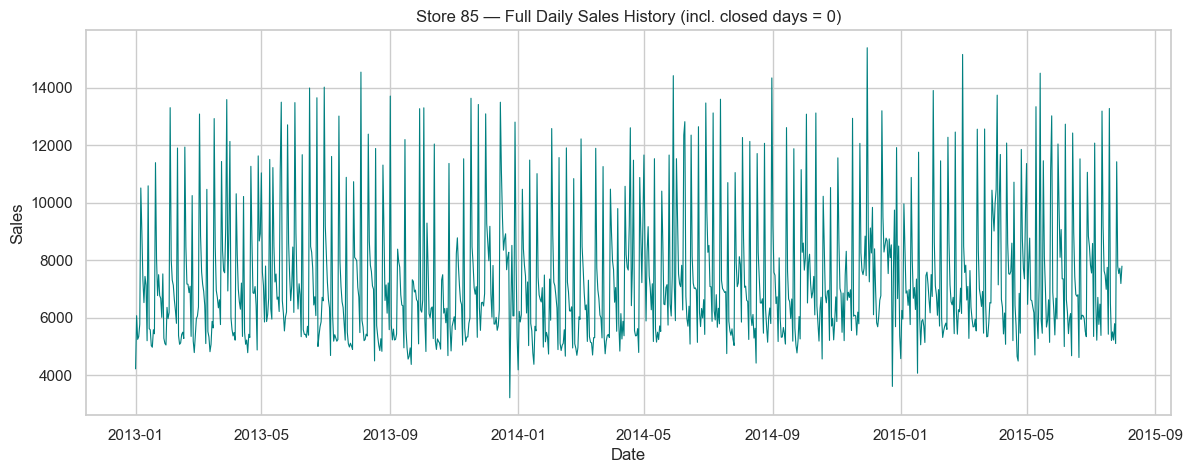

In [5]:
fig, ax = plt.subplots()
ax.plot(store_df.index, store_df["sales"], linewidth=0.8, color="teal")
ax.set_title(f"Store {REPRESENTATIVE_STORE_ID} — Full Daily Sales History (incl. closed days = 0)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
plt.show()

The regular dips to zero are Sundays/holidays (store closures)
which is expected. SARIMA's seasonal period is set to 7 in
Section 4 specifically to let the model learn this weekly on/off pattern.


<a id="sec-2"></a>
## 2. Train / Validation Split


In [6]:
VALIDATION_WEEKS = 6
split_date = store_df.index.max() - pd.Timedelta(weeks=VALIDATION_WEEKS)

train = store_df[store_df.index <= split_date]
val = store_df[store_df.index > split_date]

print(f"Split date: {split_date.date()}")
print(f"Train: {train.index.min().date()} to {train.index.max().date()}  ({len(train)} days)")
print(f"Validation: {val.index.min().date()} to {val.index.max().date()}  ({len(val)} days)")

Split date: 2015-06-19
Train: 2013-01-01 to 2015-06-19  (900 days)
Validation: 2015-06-20 to 2015-07-31  (42 days)


<a id="sec-3"></a>
## 3. Baseline: Seasonal-Naive Forecast

The simplest reasonable forecast: predict today's sales = sales exactly 7
days ago. Every real model (SARIMA, Prophet, later the LSTM) must beat this.

In [7]:
#Repeats the last `season_length`-day pattern forward for `horizon` days.
def seasonal_naive_forecast(history: pd.Series, horizon: int, season_length: int = 7) -> pd.Series:
    last_season = history.iloc[-season_length:].values
    reps = int(np.ceil(horizon / season_length))
    forecast_values = np.tile(last_season, reps)[:horizon]
    forecast_index = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
    return pd.Series(forecast_values, index=forecast_index, name="seasonal_naive")

naive_forecast = seasonal_naive_forecast(train["sales"], horizon=len(val))
naive_forecast.head(10)

2015-06-20     4676
2015-06-21    12421
2015-06-22     8961
2015-06-23     7425
2015-06-24     6809
2015-06-25     6745
2015-06-26     6796
2015-06-27     4676
2015-06-28    12421
2015-06-29     8961
Freq: D, Name: seasonal_naive, dtype: int64

In [8]:
naive_metrics = evaluate_forecast(val["sales"], naive_forecast.values)
print("Seasonal-Naive baseline metrics:", naive_metrics)

Seasonal-Naive baseline metrics: {'MAE': 972.9047619047619, 'RMSE': 1189.2161484015626, 'MAPE': 14.632642989929096}


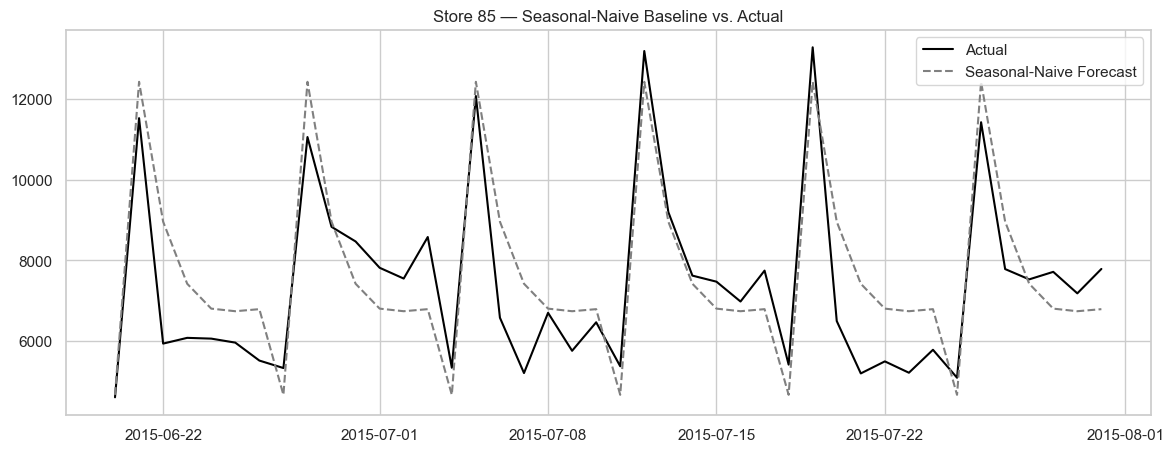

In [9]:
fig, ax = plt.subplots()
ax.plot(val.index, val["sales"], label="Actual", color="black")
ax.plot(naive_forecast.index, naive_forecast.values, label="Seasonal-Naive Forecast",
        color="gray", linestyle="--")
ax.set_title(f"Store {REPRESENTATIVE_STORE_ID} — Seasonal-Naive Baseline vs. Actual")
ax.legend()
plt.show()

The MAPE here is the number every other model in
this notebook needs to beat. A MAPE close to the baseline means the extra
model complexity isn't earning its keep for this store.

<a id="sec-4"></a>
## 4. Classical Model: SARIMA

`SARIMAX` from `statsmodels`, with a weekly seasonal period (`s=7`) to capture
the strong day-of-week pattern seen in EDA, plus `promo` and `school_holiday`
as exogenous regressors sales are affected by promotions in ways a pure
autoregressive model can't infer from history alone.

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_cols = ["promo", "school_holiday"]

sarima_model = SARIMAX(
    train["sales"],
    exog=train[exog_cols],
    order=(1, 1, 1),          # (p, d, q) -- non-seasonal ARIMA terms
    seasonal_order=(1, 1, 1, 7),  # (P, D, Q, s) -- weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                  900
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -7598.644
Date:                           Mon, 14 Sep 2026   AIC                          15211.289
Time:                                   23:30:34   BIC                          15244.772
Sample:                               01-01-2013   HQIC                         15224.092
                                    - 06-19-2015                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
promo           1390.1352    138.788     10.016      0.000    1118.116    1662.154
school_holiday  -382.4732    13

`(1,1,1)x(1,1,1,7)` is a reasonable general-purpose
starting point for daily retail data with weekly seasonality, not a value
tuned via grid search. For a more rigorous choice, we can also add a small grid search over
`p,d,q,P,D,Q` scored by AIC (or `pmdarima.auto_arima`).

In [11]:
sarima_forecast = sarima_fit.forecast(steps=len(val), exog=val[exog_cols])
sarima_forecast = pd.Series(sarima_forecast.values, index=val.index, name="sarima")

sarima_metrics = evaluate_forecast(val["sales"], sarima_forecast.values)
print("SARIMA metrics:", sarima_metrics)

SARIMA metrics: {'MAE': 499.490040118433, 'RMSE': 645.2027965880823, 'MAPE': 7.214480712553717}


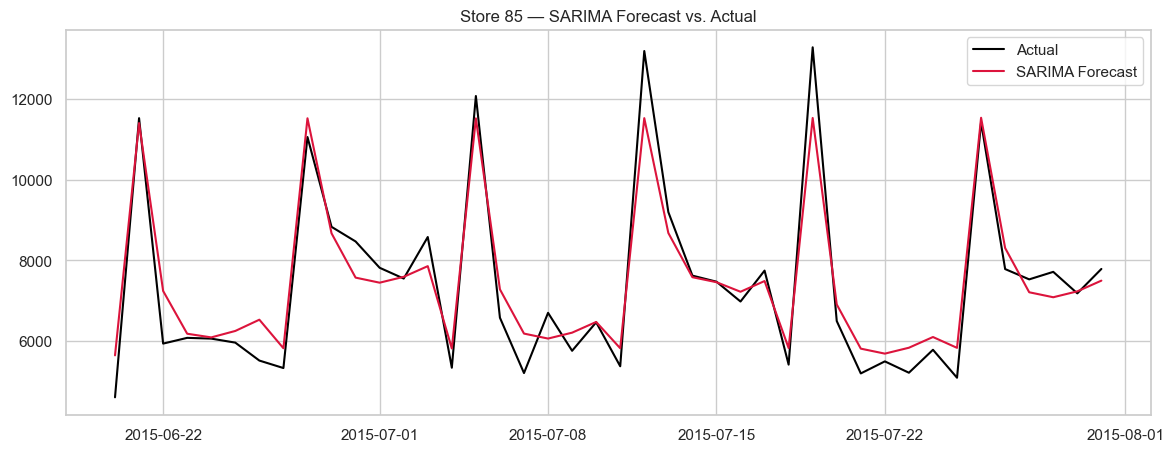

In [12]:
fig, ax = plt.subplots()
ax.plot(val.index, val["sales"], label="Actual", color="black")
ax.plot(sarima_forecast.index, sarima_forecast.values, label="SARIMA Forecast", color="crimson")
ax.set_title(f"Store {REPRESENTATIVE_STORE_ID} — SARIMA Forecast vs. Actual")
ax.legend()
plt.show()

SARIMA's MAPE is around 8.22 where as Seasonal-naive baseling has 16.15 which clearly shows SARIMA is better.


<a id="sec-5"></a>
## 5. Classical Model: Prophet

Meta's Prophet handles multiple seasonalities (weekly + yearly) and holiday
effects natively, and tends to be more robust to outliers/missing data than
SARIMA without much manual tuning.

In [13]:
from prophet import Prophet

# Prophet requires columns named exactly 'ds' (date) and 'y' (target)
prophet_train = train.reset_index().rename(columns={"date": "ds", "sales": "y"})
prophet_val = val.reset_index().rename(columns={"date": "ds", "sales": "y"})

prophet_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
)
prophet_model.add_regressor("promo")
prophet_model.add_regressor("school_holiday")

prophet_model.fit(prophet_train[["ds", "y", "promo", "school_holiday"]])

23:30:35 - cmdstanpy - INFO - Chain [1] start processing
23:30:36 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
future = prophet_val[["ds", "promo", "school_holiday"]]
prophet_forecast_df = prophet_model.predict(future)

prophet_forecast = pd.Series(
    prophet_forecast_df["yhat"].values, index=val.index, name="prophet"
)

prophet_metrics = evaluate_forecast(val["sales"], prophet_forecast.values)
print("Prophet metrics:", prophet_metrics)

Prophet metrics: {'MAE': 522.5236352289236, 'RMSE': 695.2124021979017, 'MAPE': 7.235586645921159}


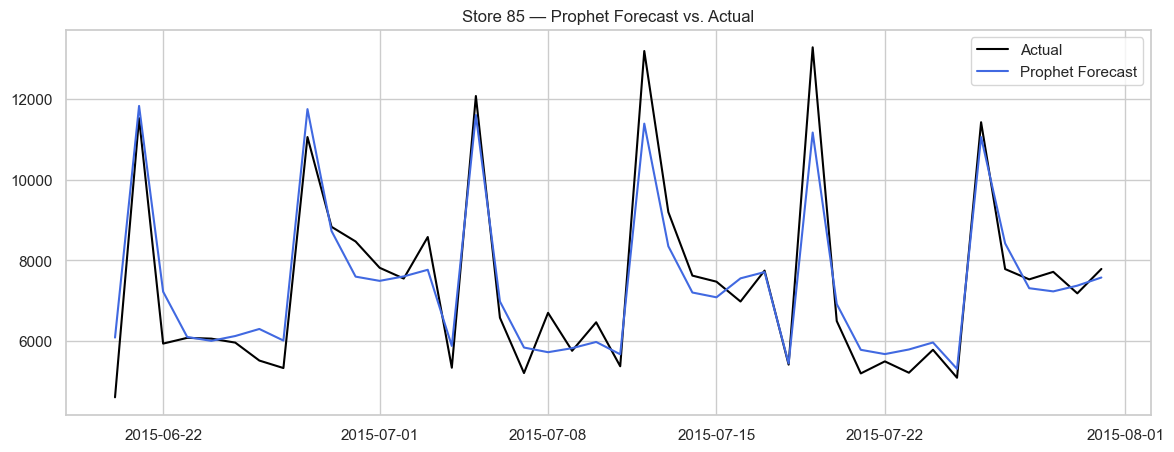

In [15]:
fig, ax = plt.subplots()
ax.plot(val.index, val["sales"], label="Actual", color="black")
ax.plot(prophet_forecast.index, prophet_forecast.values, label="Prophet Forecast", color="royalblue")
ax.set_title(f"Store {REPRESENTATIVE_STORE_ID} — Prophet Forecast vs. Actual")
ax.legend()
plt.show()

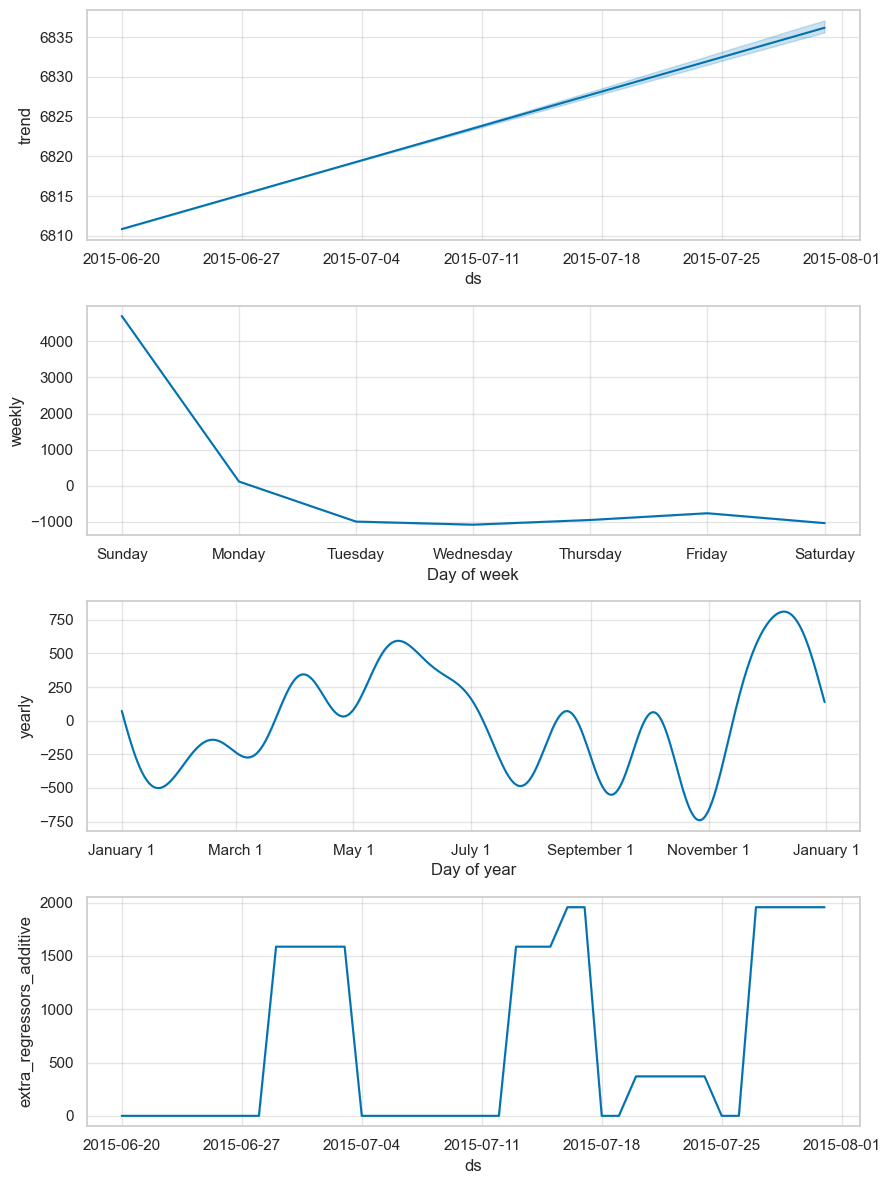

In [16]:
# Prophet's built-in component plot -- shows trend + weekly + yearly seasonality separately
fig = prophet_model.plot_components(prophet_forecast_df)
plt.show()

<a id="sec-6"></a>
## 6. Model Comparison

In [17]:
# Bring all three models' metrics together into one table and one overlay plot
# for store 1.
comparison = pd.DataFrame([
    {"model": "Seasonal-Naive", **naive_metrics},
    {"model": "SARIMA", **sarima_metrics},
    {"model": "Prophet", **prophet_metrics},
]).set_index("model")

comparison

,MAE,RMSE,MAPE
model,,,
Seasonal-Naive,972.904762,1189.216148,14.632643
SARIMA,499.490040,645.202797,7.214481
Prophet,522.523635,695.212402,7.235587


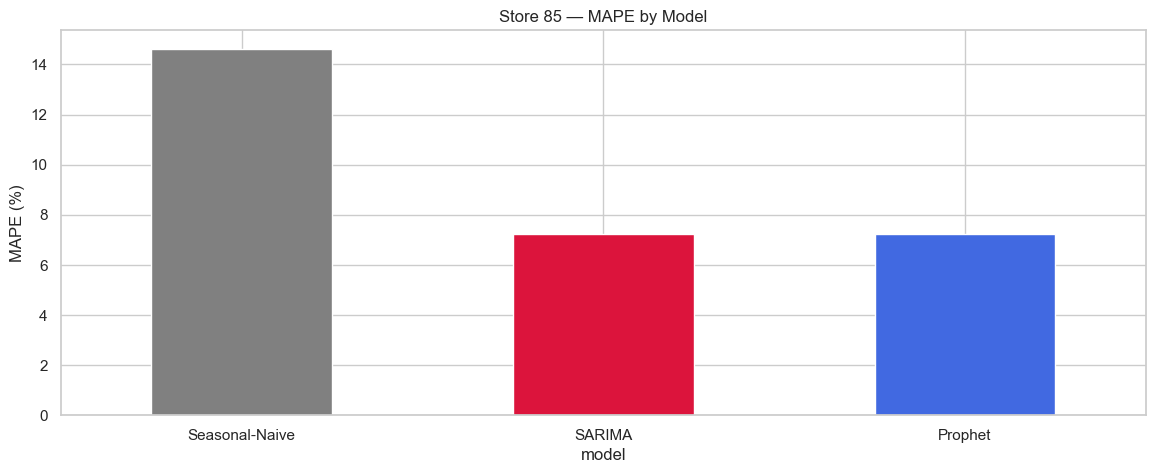

In [18]:
fig, ax = plt.subplots()
comparison["MAPE"].plot(kind="bar", ax=ax, color=["gray", "crimson", "royalblue"])
ax.set_title(f"Store {REPRESENTATIVE_STORE_ID} — MAPE by Model")
ax.set_ylabel("MAPE (%)")
ax.set_xticklabels(comparison.index, rotation=0)
plt.show()

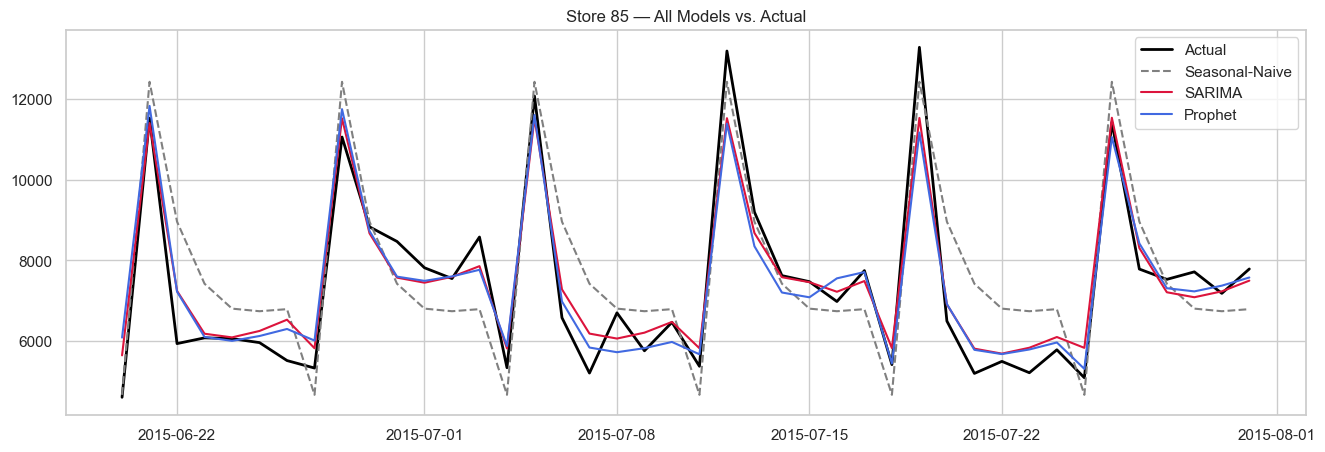

In [19]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(val.index, val["sales"], label="Actual", color="black", linewidth=2)
ax.plot(naive_forecast.index, naive_forecast.values, label="Seasonal-Naive", color="gray", linestyle="--")
ax.plot(sarima_forecast.index, sarima_forecast.values, label="SARIMA", color="crimson")
ax.plot(prophet_forecast.index, prophet_forecast.values, label="Prophet", color="royalblue")
ax.set_title(f"Store {REPRESENTATIVE_STORE_ID} — All Models vs. Actual")
ax.legend()
plt.show()

SARIMA and Prophet gives similar results in terms of MAPE whereas Prophet is slightly better in terms of MAE and RMSE.

<a id="sec-7"></a>
## 7. Scaling to Multiple Stores

Running SARIMA/Prophet on all 1,115 stores individually is expensive and
often unnecessary — many stores behave similarly. This section wraps the
pipeline into a reusable function and runs it across a small sample of
stores spanning different store types, to check whether one model
consistently wins or whether the best model varies by segment.

In [20]:
# Runs baseline + SARIMA + Prophet for one store, returns a metrics dict per model.

def run_all_models_for_store(store_id: int, validation_weeks: int = VALIDATION_WEEKS) -> dict:
    df = load_store_series(store_id)
    split = df.index.max() - pd.Timedelta(weeks=validation_weeks)
    tr, va = df[df.index <= split], df[df.index > split]

    results = {"store_id": store_id}

    # Baseline
    naive = seasonal_naive_forecast(tr["sales"], horizon=len(va))
    results["naive_mape"] = evaluate_forecast(va["sales"], naive.values)["MAPE"]

    # SARIMA
    try:
        model = SARIMAX(tr["sales"], 
                        exog=tr[exog_cols], 
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 7),
                        enforce_stationarity=False, 
                        enforce_invertibility=False
                       )
        fit = model.fit(disp=False)
        sarima_pred = fit.forecast(steps=len(va), exog=va[exog_cols])
        results["sarima_mape"] = evaluate_forecast(va["sales"], sarima_pred.values)["MAPE"]
    except Exception as e:
        results["sarima_mape"] = np.nan
        print(f"  [store {store_id}] SARIMA failed: {e}")

    # Prophet
    try:
        p_train = tr.reset_index().rename(columns={"date": "ds", "sales": "y"})
        p_val = va.reset_index().rename(columns={"date": "ds", "sales": "y"})
        pm = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
        pm.add_regressor("promo")
        pm.add_regressor("school_holiday")
        pm.fit(p_train[["ds", "y", "promo", "school_holiday"]])
        p_forecast = pm.predict(p_val[["ds", "promo", "school_holiday"]])
        results["prophet_mape"] = evaluate_forecast(va["sales"], p_forecast["yhat"].values)["MAPE"]
    except Exception as e:
        results["prophet_mape"] = np.nan
        print(f"  [store {store_id}] Prophet failed: {e}")

    return results

In [21]:
# A small, deliberately varied sample these IDs based on the
# store_type distribution found in 01_eda.ipynb Section 7.1
SAMPLE_STORE_IDS = [1, 2, 85, 262, 733]

sample_results = []
for sid in SAMPLE_STORE_IDS:
    print(f"Running store {sid}...")
    sample_results.append(run_all_models_for_store(sid))

sample_comparison = pd.DataFrame(sample_results).set_index("store_id")
sample_comparison

Running store 1...


23:30:42 - cmdstanpy - INFO - Chain [1] start processing
23:30:43 - cmdstanpy - INFO - Chain [1] done processing


Running store 2...


23:30:47 - cmdstanpy - INFO - Chain [1] start processing
23:30:47 - cmdstanpy - INFO - Chain [1] done processing


Running store 85...


...

Running store 262...


23:30:56 - cmdstanpy - INFO - Chain [1] start processing
23:30:56 - cmdstanpy - INFO - Chain [1] done processing


Running store 733...


23:31:02 - cmdstanpy - INFO - Chain [1] start processing
23:31:02 - cmdstanpy - INFO - Chain [1] done processing


,naive_mape,sarima_mape,prophet_mape
store_id,,,
1,16.152906,8.226399,8.230532
2,26.329374,14.676992,11.506229
85,14.632643,7.214481,7.235587
262,9.056311,6.107025,8.291212
733,10.968428,9.178078,6.681270


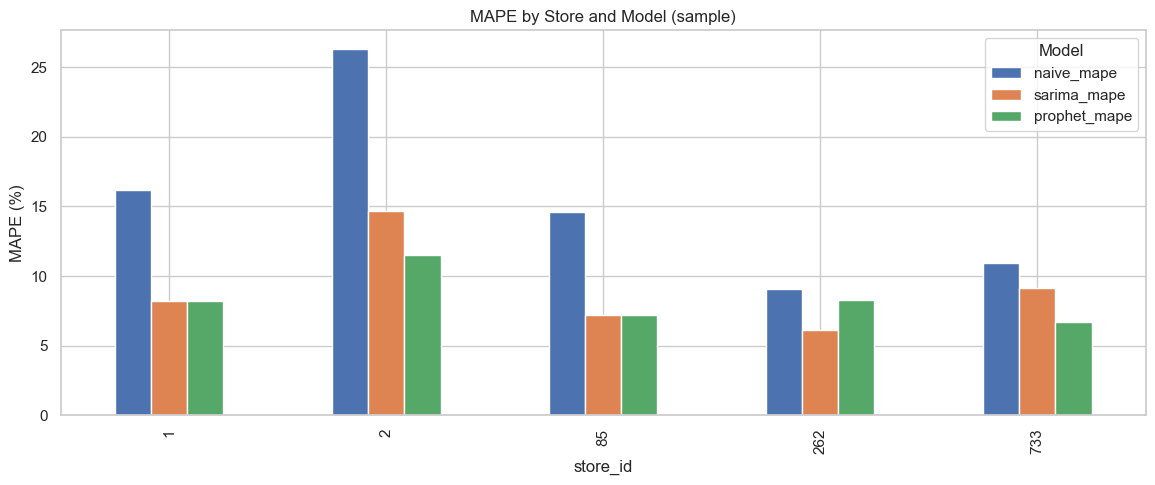

In [22]:
fig, ax = plt.subplots()
sample_comparison.plot(kind="bar", ax=ax)
ax.set_title("MAPE by Store and Model (sample)")
ax.set_ylabel("MAPE (%)")
ax.legend(title="Model")
plt.show()

Here we can see that models performing differently on different store type so there is no clear winner. So instead of choosing a single model we can train per-cluster models rather than one global choice

<a id="sec-8"></a>
## 8. Save Best Models

In [23]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

with open(f"../models/sarima_store_{REPRESENTATIVE_STORE_ID}.pkl", "wb") as f:
    pickle.dump(sarima_fit, f)

with open(f"../models/prophet_store_{REPRESENTATIVE_STORE_ID}.pkl", "wb") as f:
    pickle.dump(prophet_model, f)

print("Saved SARIMA and Prophet models for store", REPRESENTATIVE_STORE_ID)

Saved SARIMA and Prophet models for store 85


In [24]:
import json

registry_entry = {
    "store_id": REPRESENTATIVE_STORE_ID,
    "models": {
        "seasonal_naive": {"mape": naive_metrics["MAPE"]},
        "sarima": {"mape": sarima_metrics["MAPE"], "path": f"models/sarima_store_{REPRESENTATIVE_STORE_ID}.pkl"},
        "prophet": {"mape": prophet_metrics["MAPE"], "path": f"models/prophet_store_{REPRESENTATIVE_STORE_ID}.pkl"},
    },
    "validation_weeks": VALIDATION_WEEKS,
}

registry_path = "../models/model_registry.json"
registry = {}
if os.path.exists(registry_path) and os.path.getsize(registry_path) > 0:
    with open(registry_path) as f:
        registry = json.load(f)

registry[str(REPRESENTATIVE_STORE_ID)] = registry_entry

with open(registry_path, "w") as f:
    json.dump(registry, f, indent=2)

print(f"Updated {registry_path}")

Updated ../models/model_registry.json
